<a href="https://colab.research.google.com/github/Madhankoppera/Dissertation-Code/blob/main/Dissertation_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setups&Imports

In [ ]:
import os, math, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sps
from scipy.stats import kurtosis, skew

import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import SVC # Added for SVM
from sklearn.neighbors      import KNeighborsClassifier # Added for KNN
from sklearn.metrics        import (accuracy_score, classification_report,
                                    confusion_matrix, ConfusionMatrixDisplay,
                                    f1_score)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow', tf.__version__, '· GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow 2.20.0 · GPU available: True


Multi Color Noise

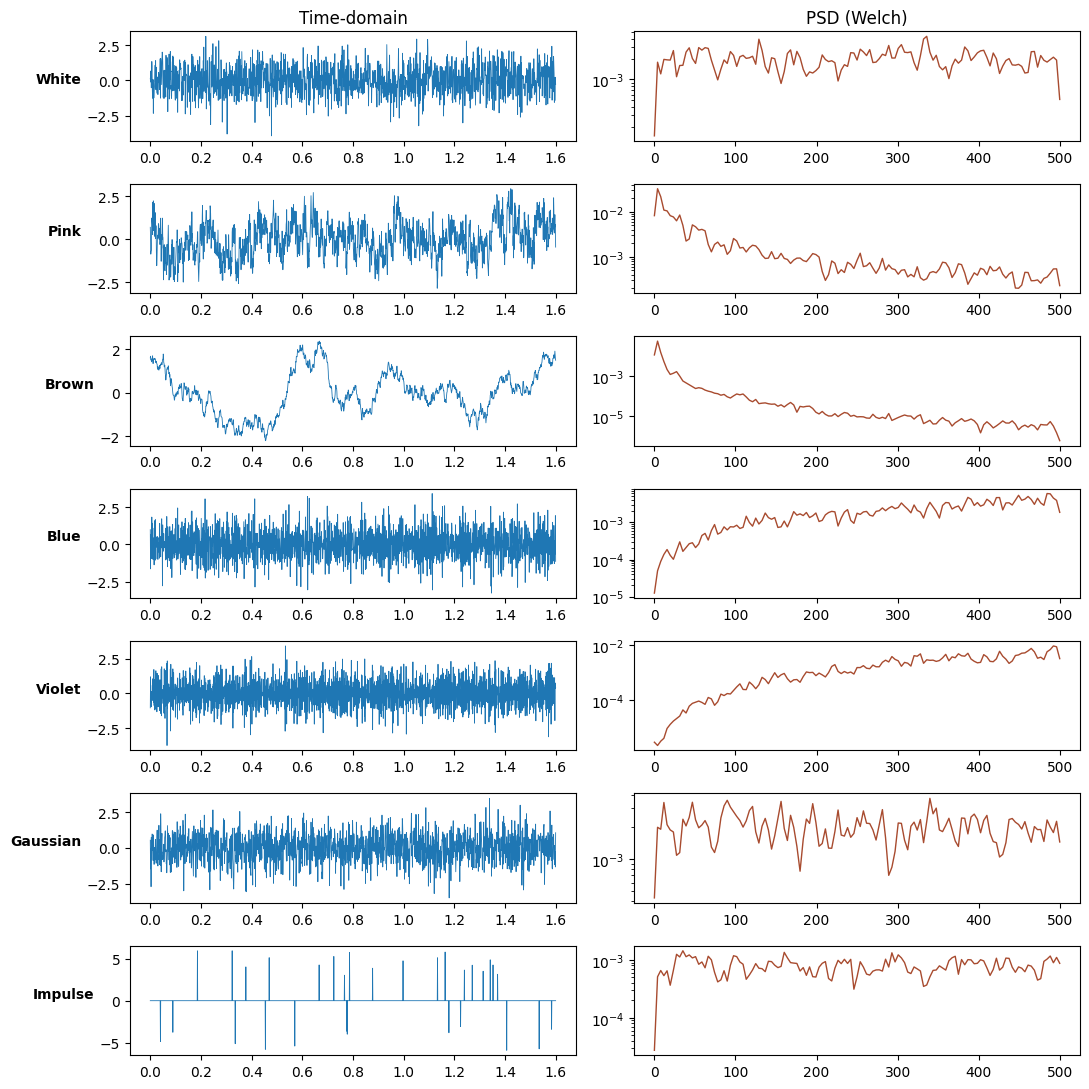

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps

FS = 1000          # sampling rate (Hz)
N  = 1600          # samples per segment (~ 1 s at FS=1000)

def colored_noise(n=N, beta=0.0, fs=FS, rng=None):
    """Generate 1-D colored noise of length n with PSD slope -beta."""
    rng = rng or np.random.default_rng()
    # white spectrum
    white = rng.standard_normal(n)
    f = np.fft.rfftfreq(n, d=1/fs)
    f[0] = f[1]                        # avoid division by zero at DC
    spectrum = np.fft.rfft(white)
    spectrum = spectrum / (f ** (beta/2.0))   # shape PSD by 1/f^beta
    out = np.fft.irfft(spectrum, n=n)
    out = (out - out.mean()) / (out.std() + 1e-12)   # zero-mean, unit-variance
    return out.astype(np.float32)

def gaussian_noise(n=N, rng=None):
    rng = rng or np.random.default_rng()
    x = rng.standard_normal(n).astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-12)

def impulse_noise(n=N, prob=0.02, amp=6.0, rng=None):
    rng = rng or np.random.default_rng()
    x = np.zeros(n, dtype=np.float32)
    mask = rng.random(n) < prob
    x[mask] = rng.choice([-1, 1], size=mask.sum()) * rng.uniform(amp/2, amp, mask.sum())
    return x
    # quick visual check of every noise class
rng = np.random.default_rng(0)
classes = {
    'White'   : colored_noise(beta= 0, rng=rng),
    'Pink'    : colored_noise(beta=+1, rng=rng),
    'Brown'   : colored_noise(beta=+2, rng=rng),
    'Blue'    : colored_noise(beta=-1, rng=rng),
    'Violet'  : colored_noise(beta=-2, rng=rng),
    'Gaussian': gaussian_noise(rng=rng),
    'Impulse' : impulse_noise(rng=rng),
}
fig, axes = plt.subplots(7, 2, figsize=(11, 11))
t = np.arange(N)/FS
for i, (name, x) in enumerate(classes.items()):
    axes[i,0].plot(t, x, lw=0.6); axes[i,0].set_ylabel(name, rotation=0, ha='right', fontweight='bold')
    f, P = sps.welch(x, fs=FS, nperseg=256)
    axes[i,1].semilogy(f, P, color='#A84B2F', lw=1)
    if i == 0:
        axes[i,0].set_title('Time-domain'); axes[i,1].set_title('PSD (Welch)')
plt.tight_layout(); plt.show()

Mixing the 7 Noise Types

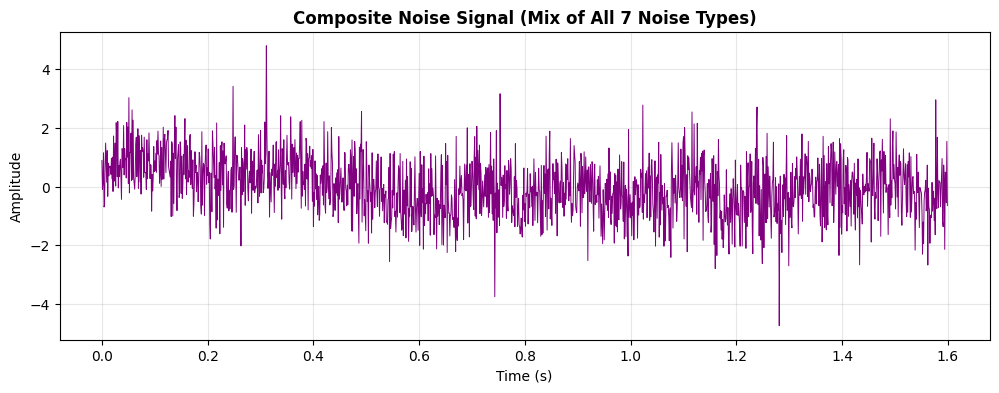

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps
from scipy.fft import rfft, irfft, rfftfreq

FS = 1000          # sampling rate (Hz)
N  = 1600          # samples per segment (~ 1 s at FS=1000)
SEED = 42          # Seed for reproducibility

def generate_colored_noise(beta, n_samples=N, fs=FS):
    """
    Generates colored noise using the FFT-shaping formula (Appendix B of Dissertation).
    beta values: 0 (White), 1 (Pink), 2 (Brown), -1 (Blue), -2 (Violet)
    """
    # 1. Generate White Gaussian Noise in time domain
    white_noise = np.random.normal(0, 1, n_samples)

    # 2. Transform to Frequency Domain
    fft_coeffs = rfft(white_noise)
    frequencies = rfftfreq(n_samples, d=1/fs)

    # Avoid division by zero at the DC component (0Hz)
    frequencies[0] = frequencies[1] # Set DC component frequency to a non-zero value to prevent division by zero

    # 3. Apply the Shaping Filter: H(f) = 1 / f^(beta/2)
    # The power spectrum S(f) is proportional to 1 / f^beta
    shaping_filter = 1 / (frequencies ** (beta / 2.0))
    shaped_fft = fft_coeffs * shaping_filter

    # 4. Transform back to Time Domain
    colored_noise = irfft(shaped_fft, n=n_samples)

    # 5. Normalize to zero mean and unit variance
    colored_noise = (colored_noise - np.mean(colored_noise)) / (np.std(colored_noise) + 1e-12)

    return colored_noise

def gaussian_noise(n=N, rng=None):
    rng = rng or np.random.default_rng()
    x = rng.standard_normal(n).astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-12)

def impulse_noise(n=N, prob=0.02, amp=6.0, rng=None):
    rng = rng or np.random.default_rng()
    x = np.zeros(n, dtype=np.float32)
    mask = rng.random(n) < prob
    x[mask] = rng.choice([-1, 1], size=mask.sum()) * rng.uniform(amp/2, amp, mask.sum())
    return x

def generate_all_noise_mixture(n=N, fs=FS, rng=None):
    """
    Superimposes all 7 noise types into a single composite signal.
    Weights are distributed evenly to ensure no single noise dominates.
    """
    rng = rng or np.random.default_rng()

    # Define all base noise types
    noise_types = {
        'white':    generate_colored_noise(0, n_samples=n, fs=fs),
        'pink':     generate_colored_noise(1, n_samples=n, fs=fs),
        'brown':    generate_colored_noise(2, n_samples=n, fs=fs),
        'blue':     generate_colored_noise(-1, n_samples=n, fs=fs),
        'violet':   generate_colored_noise(-2, n_samples=n, fs=fs),
        'gaussian': gaussian_noise(n=n, rng=rng),
        'impulse':  impulse_noise(n=n, rng=rng)
    }

    # 1. Create equal weights (1/7 for each)
    weight = 1.0 / len(noise_types)
    composite_signal = np.zeros(n, dtype=np.float32)

    # 2. Sum them up
    for name, signal in noise_types.items():
        composite_signal += weight * signal

    # 3. Final normalization to unit variance
    composite_signal = (composite_signal - np.mean(composite_signal)) / (np.std(composite_signal) + 1e-12)

    return composite_signal

# --- Visualization ---
rng = np.random.default_rng(SEED)
all_mixed = generate_all_noise_mixture(rng=rng)
t = np.arange(N)/FS

plt.figure(figsize=(12, 4))
plt.plot(t, all_mixed, lw=0.7, color='purple')
plt.title("Composite Noise Signal (Mix of All 7 Noise Types)", fontweight='bold')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.show()

Dataset Construction

In [ ]:
import numpy as np
import scipy.signal as sps
from scipy.fft import rfft, irfft, rfftfreq # Added for generate_colored_noise

FS = 1000          # sampling rate (Hz)
N  = 1600          # samples per segment (~ 1 s at FS=1000)

LABELS = ['white','pink','brown','blue','violet','gaussian','impulse','mixed']
SAMPLES_PER_CLASS = 1600          # ↓ reduce to 600 for a fast preview run
SNR_RANGE = (-5, 30)              # dB
SEED = 42 # Define SEED explicitly within this cell

def generate_colored_noise(beta, n_samples=N, fs=FS):
    """
    Generates colored noise using the FFT-shaping formula (Appendix B of Dissertation).
    beta values: 0 (White), 1 (Pink), 2 (Brown), -1 (Blue), -2 (Violet)
    """
    # 1. Generate White Gaussian Noise in time domain
    white_noise = np.random.normal(0, 1, n_samples)

    # 2. Transform to Frequency Domain
    fft_coeffs = rfft(white_noise)
    frequencies = rfftfreq(n_samples, d=1/fs)

    # Avoid division by zero at the DC component (0Hz)
    frequencies[0] = frequencies[1] # Set DC component frequency to a non-zero value to prevent division by zero

    # 3. Apply the Shaping Filter: H(f) = 1 / f^(beta/2)
    # The power spectrum S(f) is proportional to 1 / f^beta
    shaping_filter = 1 / (frequencies ** (beta / 2.0))
    shaped_fft = fft_coeffs * shaping_filter

    # 4. Transform back to Time Domain
    colored_noise = irfft(shaped_fft, n=n_samples)

    # 5. Normalize to zero mean and unit variance
    colored_noise = (colored_noise - np.mean(colored_noise)) / (np.std(colored_noise) + 1e-12)

    return colored_noise

def gaussian_noise(n=N, rng=None):
    rng = rng or np.random.default_rng()
    x = rng.standard_normal(n).astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-12)

def impulse_noise(n=N, prob=0.02, amp=6.0, rng=None):
    rng = rng or np.random.default_rng()
    x = np.zeros(n, dtype=np.float32)
    mask = rng.random(n) < prob
    x[mask] = rng.choice([-1, 1], size=mask.sum()) * rng.uniform(amp/2, amp, mask.sum())
    return x

def mixed_noise(n=N, k=3, rng=None):
    """Random mixture of k different base noise classes."""
    rng = rng or np.random.default_rng()
    pool = ['white', 'pink', 'brown', 'blue', 'violet', 'gaussian', 'impulse']
    chosen = rng.choice(pool, size=k, replace=False)
    weights = rng.dirichlet(np.ones(k))            # weights sum to 1
    out = np.zeros(n, dtype=np.float32)
    for w, name in zip(weights, chosen):
        if name == 'white':    comp = generate_colored_noise(0, n_samples=n, fs=FS,)
        elif name == 'pink':   comp = generate_colored_noise(+1, n_samples=n, fs=FS)
        elif name == 'brown':  comp = generate_colored_noise(+2, n_samples=n, fs=FS)
        elif name == 'blue':   comp = generate_colored_noise(-1, n_samples=n, fs=FS)
        elif name == 'violet': comp = generate_colored_noise(-2, n_samples=n, fs=FS)
        elif name == 'gaussian': comp = gaussian_noise(n=N, rng=rng)
        elif name == 'impulse':  comp = impulse_noise(n=N, rng=rng)
        out += w * comp
    return out / (out.std() + 1e-12)

def random_clean_signal(n=N, fs=FS, rng=None):
    rng = rng or np.random.default_rng()
    kind = rng.choice(['sine','multitone','chirp'])
    t = np.arange(n)/fs
    if kind == 'sine':
        f = rng.uniform(2, 30)
        s = np.sin(2*np.pi*f*t)
    elif kind == 'multitone':
        s = sum(rng.uniform(0.3,1.0)*np.sin(2*np.pi*rng.uniform(2,40)*t) for _ in range(3))
    else:
        s = sps.chirp(t, f0=2, f1=40, t1=t[-1], method='linear')
    return (s/np.std(s)).astype(np.float32)

def add_noise_at_snr(clean, noise, snr_db, rng=None):
    rng = rng or np.random.default_rng()
    Ps = np.mean(clean**2)
    Pn = np.mean(noise**2) + 1e-12
    target_pn = Ps / (10 ** (snr_db / 10))
    scale = np.sqrt(target_pn / Pn)
    return (clean + scale*noise).astype(np.float32), float(snr_db)

def synth_one(label, rng):
    clean = random_clean_signal(rng=rng)
    if   label == 'white':    n = generate_colored_noise(beta=0, n_samples=N, fs=FS)
    elif label == 'pink':     n = generate_colored_noise(+1, n_samples=N, fs=FS)
    elif label == 'brown':    n = generate_colored_noise(+2, n_samples=N, fs=FS)
    elif label == 'blue':     n = generate_colored_noise(-1, n_samples=N, fs=FS)
    elif label == 'violet':   n = generate_colored_noise(-2, n_samples=N, fs=FS)
    elif label == 'gaussian': n = gaussian_noise(n=N, rng=rng)
    elif label == 'impulse':  n = impulse_noise(n=N, rng=rng)
    elif label == 'mixed':    n = mixed_noise(n=N, rng=rng)
    snr = rng.uniform(*SNR_RANGE)
    noisy, snr_db = add_noise_at_snr(clean, n, snr, rng=rng)
    return clean, noisy, snr_db

def build_dataset(samples_per_class=SAMPLES_PER_CLASS, seed=SEED):
    rng = np.random.default_rng(seed)
    cleans, noisies, ys, snrs = [], [], [], []
    for cls in LABELS:
        for _ in range(samples_per_class):
            c, x, s = synth_one(cls, rng)
            cleans.append(c); noisies.append(x); ys.append(cls); snrs.append(s)
    return (np.stack(cleans), np.stack(noisies),
            np.array(ys), np.array(snrs, dtype=np.float32))

print('Generating dataset … this takes ~30 s')
clean_arr, noisy_arr, y_arr, snr_arr = build_dataset()
print('Shapes:', noisy_arr.shape, y_arr.shape, snr_arr.shape)

Generating dataset … this takes ~30 s
Shapes: (12800, 1600) (12800,) (12800,)


Advance Feature Extraction

In [ ]:
def spectral_entropy(x, fs=FS):
    f, P = sps.welch(x, fs=fs, nperseg=256)
    P = P / (P.sum() + 1e-12)
    return float(-np.sum(P * np.log2(P + 1e-12)))

def spectral_features(x, fs=FS):
    f, P = sps.welch(x, fs=fs, nperseg=256)
    P_norm = P / (P.sum() + 1e-12)
    energy   = np.sum(P)
    centroid = np.sum(f * P_norm)
    rolloff_idx = np.searchsorted(np.cumsum(P_norm), 0.85)
    rolloff  = f[min(rolloff_idx, len(f)-1)]
    bw       = np.sqrt(np.sum(((f - centroid)**2) * P_norm))
    flux     = float(np.sqrt(np.mean(np.diff(P)**2)))
    ent      = -np.sum(P_norm * np.log2(P_norm + 1e-12))
    return [energy, centroid, rolloff, bw, flux, ent]

def temporal_features(x):
    zcr  = float(((x[:-1]*x[1:]) < 0).mean())
    rms  = float(np.sqrt(np.mean(x**2)))
    peak = float(np.max(np.abs(x)) / (rms + 1e-12))
    return [zcr, rms, peak]

def stat_features(x):
    return [float(kurtosis(x)), float(skew(x))]

def mfcc_features(x, fs=FS, n_mfcc=13):
    M = librosa.feature.mfcc(y=x.astype(np.float32), sr=fs, n_mfcc=n_mfcc, n_fft=256, hop_length=128)
    return M.mean(axis=1).tolist()

FEATURE_NAMES = (
    ['spec_energy','spec_centroid','spec_rolloff','spec_bw','spec_flux','spec_entropy']
    + ['zcr','rms','peak']
    + ['kurtosis','skew']
    + [f'mfcc_{i+1}' for i in range(13)]
)

def extract_features(x):
    return np.array(spectral_features(x) + temporal_features(x)
                    + stat_features(x) + mfcc_features(x),
                    dtype=np.float32)

print('Feature dimension =', len(FEATURE_NAMES))
# Extract the full feature matrix (vectorized loop, ~30 s)
print('Extracting features for', len(noisy_arr), 'segments …')
t0 = time.time()
X_feat = np.stack([extract_features(x) for x in noisy_arr])
print(f'Done in {time.time()-t0:.1f}s — X_feat shape {X_feat.shape}')

Feature dimension = 24
Extracting features for 12800 segments …
Done in 72.6s — X_feat shape (12800, 24)


Random Forest vs Decision Tree

Decision Tree  test accuracy : 74.88 %
Random Forest  test accuracy : 78.16 %
Improvement                  : +3.28 pp


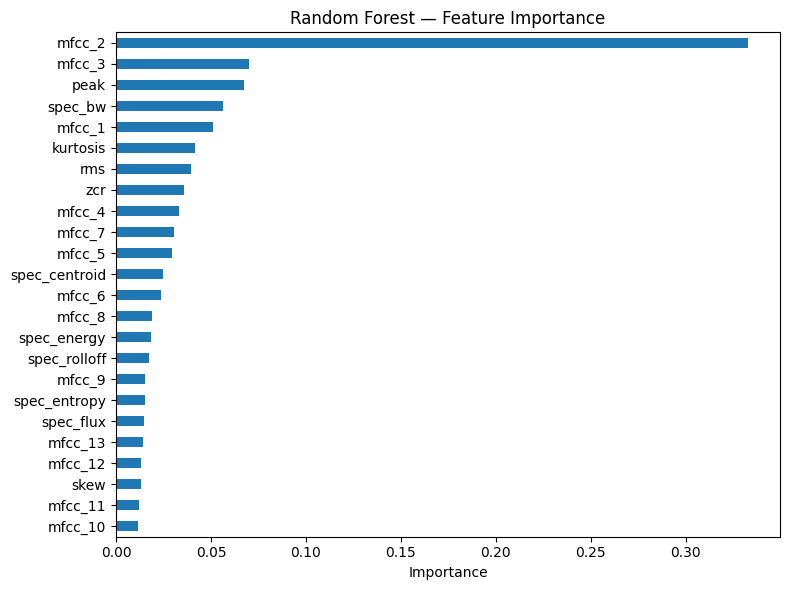

In [ ]:
# Encode labels and split
le = LabelEncoder().fit(LABELS)
y_enc = le.transform(y_arr)

X_tr, X_te, y_tr, y_te, snr_tr, snr_te = train_test_split(
    X_feat, y_enc, snr_arr, test_size=0.20, stratify=y_enc, random_state=SEED)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)

dt = DecisionTreeClassifier(max_depth=12, random_state=SEED).fit(X_tr_s, y_tr)
rf = RandomForestClassifier(n_estimators=200, max_depth=14,
                            n_jobs=-1, random_state=SEED).fit(X_tr_s, y_tr)

acc_dt = accuracy_score(y_te, dt.predict(X_te_s))
acc_rf = accuracy_score(y_te, rf.predict(X_te_s))
print(f'Decision Tree  test accuracy : {acc_dt*100:.2f} %')
print(f'Random Forest  test accuracy : {acc_rf*100:.2f} %')
print(f'Improvement                  : +{(acc_rf-acc_dt)*100:.2f} pp')
# Random-forest feature importance plot
importances = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values()
plt.figure(figsize=(8,6))
importances.plot.barh(color='#1F77B4')
plt.title('Random Forest — Feature Importance'); plt.xlabel('Importance')
plt.tight_layout(); plt.show()

Accuracy of SVM and KNN

In [ ]:
# Initialize and train SVM and KNN models
svm = SVC(kernel='rbf', C=1.5, random_state=SEED).fit(X_tr_s, y_tr)
knn = KNeighborsClassifier(n_neighbors=5).fit(X_tr_s, y_tr)

# Calculate Accuracy
acc_svm = accuracy_score(y_te, svm.predict(X_te_s)) * 100
acc_knn = accuracy_score(y_te, knn.predict(X_te_s)) * 100

print(f"SVM Test Accuracy: {acc_svm:.2f}%")
print(f"KNN Test Accuracy: {acc_knn:.2f}%")

SVM Test Accuracy: 77.50%
KNN Test Accuracy: 71.09%


Accuracy Comparison of RF/DT/SVN/KNN

,Model,Test Acc (%)
0,Decision Tree,74.882812
1,Random Forest,78.164062
2,SVM,77.500000
3,KNN,71.093750


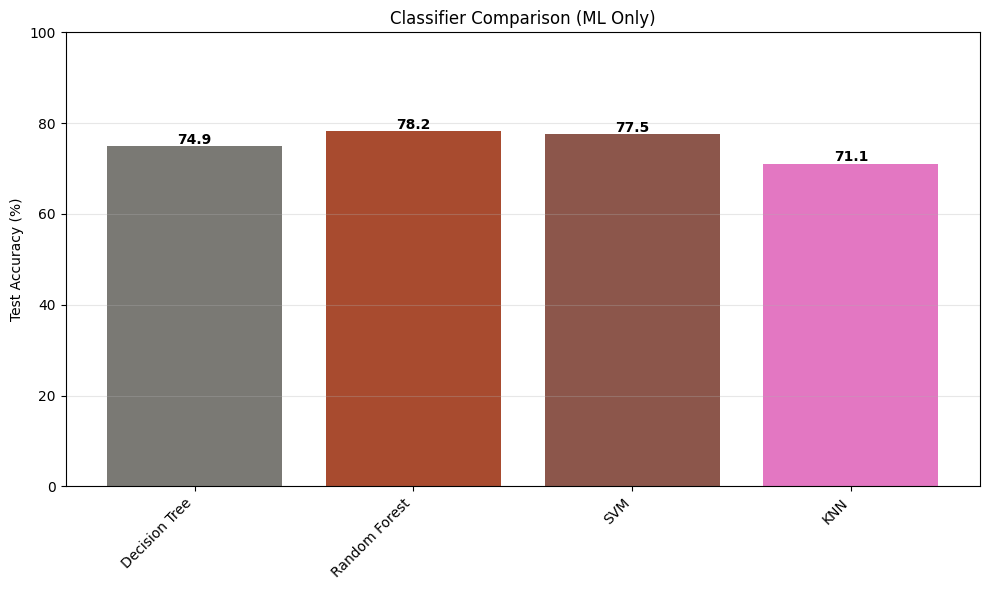

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# CNN model and adaptive system are removed.
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'SVM', 'KNN'],
    'Test Acc (%)': [acc_dt*100, acc_rf*100, acc_svm, acc_knn],
})

display(results)

plt.figure(figsize=(10, 6))
# Adjust colors to match the remaining models, keeping the original order for those models
plt.bar(results['Model'], results['Test Acc (%)'],
        color=['#7A7974','#A84B2F','#8c564b','#e377c2']) # Original colors for DT, RF, SVM, KNN

plt.ylim(0, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('Classifier Comparison (ML Only)') # Update title to reflect change
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(results['Test Acc (%)']):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Confusion Matrix

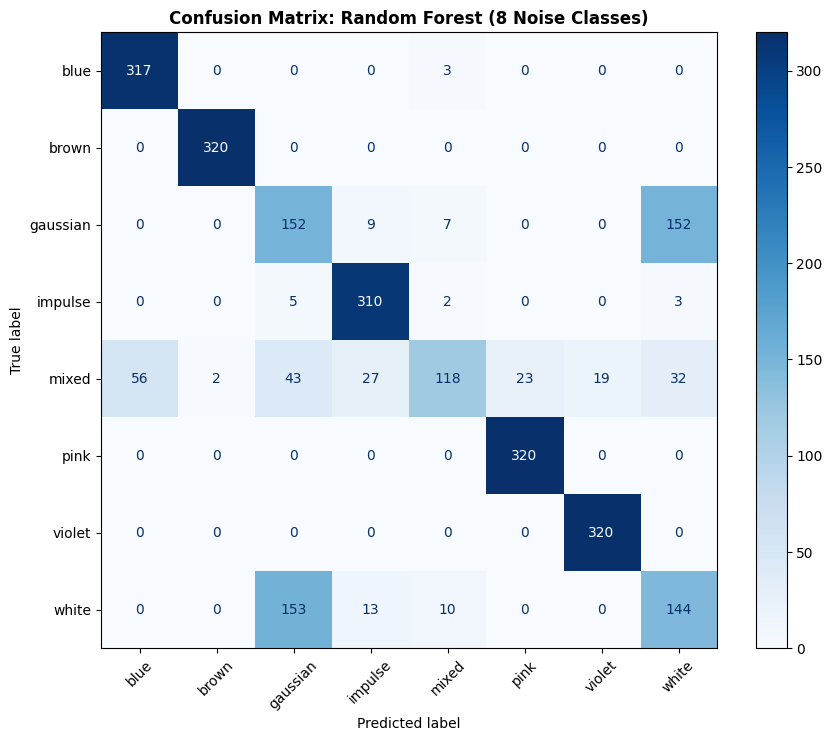

              precision    recall  f1-score   support

        blue       0.85      0.99      0.91       320
       brown       0.99      1.00      1.00       320
    gaussian       0.43      0.47      0.45       320
     impulse       0.86      0.97      0.91       320
       mixed       0.84      0.37      0.51       320
        pink       0.93      1.00      0.97       320
      violet       0.94      1.00      0.97       320
       white       0.44      0.45      0.44       320

    accuracy                           0.78      2560
   macro avg       0.79      0.78      0.77      2560
weighted avg       0.79      0.78      0.77      2560



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate predictions using your trained Random Forest
y_pred_rf = rf.predict(X_te_s)

# 2. Create the confusion matrix
cm_rf = confusion_matrix(y_te, y_pred_rf)

# 3. Plot the matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)

disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix: Random Forest (8 Noise Classes)', fontweight='bold')
plt.show()

# 4. Detailed Report
from sklearn.metrics import classification_report
print(classification_report(y_te, y_pred_rf, target_names=le.classes_))

Model classification vs Input SNR

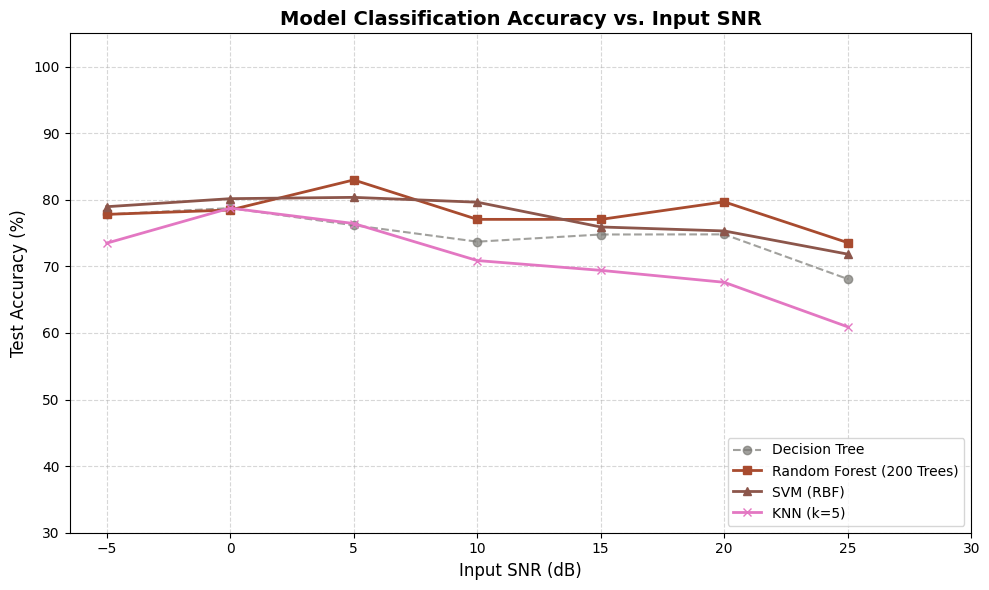

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Define SNR bins (matching the -5 to 30 dB range in your Chapter 4.1)
snr_bins = np.arange(-5, 35, 5)
dt_accs, rf_accs, svm_accs, knn_accs = [], [], [], []

# 2. Iterate through each bin to calculate accuracy
for bin_val in snr_bins:
    # Create a mask for samples within the current SNR range
    mask = (snr_te >= bin_val) & (snr_te < bin_val + 5)

    if np.sum(mask) > 0:
        # Calculate accuracy for each ML model using the masked test set
        dt_accs.append(accuracy_score(y_te[mask], dt.predict(X_te_s[mask])) * 100)
        rf_accs.append(accuracy_score(y_te[mask], rf.predict(X_te_s[mask])) * 100)
        svm_accs.append(accuracy_score(y_te[mask], svm.predict(X_te_s[mask])) * 100)
        knn_accs.append(accuracy_score(y_te[mask], knn.predict(X_te_s[mask])) * 100)
    else:
        # Handle empty bins
        dt_accs.append(None); rf_accs.append(None)
        svm_accs.append(None); knn_accs.append(None)

# 3. Plotting the results
plt.figure(figsize=(10, 6))

plt.plot(snr_bins, dt_accs, 'o--', label='Decision Tree', color='#7A7974', alpha=0.7)
plt.plot(snr_bins, rf_accs, 's-',  label='Random Forest (200 Trees)', color='#A84B2F', linewidth=2)
plt.plot(snr_bins, svm_accs, '^-',  label='SVM (RBF)', color='#8c564b', linewidth=2)
plt.plot(snr_bins, knn_accs, 'x-',  label='KNN (k=5)', color='#e377c2', linewidth=2)


plt.title('Model Classification Accuracy vs. Input SNR', fontsize=14, fontweight='bold')
plt.xlabel('Input SNR (dB)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.xticks(snr_bins)
plt.ylim(30, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Denoising Pipeline

In [ ]:
import numpy as np
import scipy.signal as sps
import pywt

FS = 1000 # Define FS here as well for self-containment

def estimate_snr_db(x, fs=FS):
    """Cheap SNR proxy from spectral flatness + amplitude statistics."""
    f, P = sps.welch(x, fs=fs, nperseg=256)
    P = P + 1e-12
    flatness = np.exp(np.mean(np.log(P))) / np.mean(P)   # 0 … 1
    # map flatness ∈ [0,1]  →  SNR ∈ [+25 dB,  -5 dB]
    snr_est = 25 - 30*flatness
    return float(np.clip(snr_est, -10, 35))

def snr_db(clean, noisy):
    Ps = np.mean(clean**2); Pn = np.mean((noisy-clean)**2) + 1e-12
    return 10*np.log10(Ps / Pn)

# --- Denoising Functions (Moved from hguA932lzgD-) ---
def lowpass(x, fs=FS, fc=80, order=4):
    b, a = sps.butter(order, fc/(fs/2), btype='low'); return sps.filtfilt(b, a, x)

def highpass(x, fs=FS, fc=10, order=4):
    b, a = sps.butter(order, fc/(fs/2), btype='high'); return sps.filtfilt(b, a, x)

def median_denoise(x, k=5):
    return sps.medfilt(x, kernel_size=k)

def spectral_whitening(x):
    X = np.fft.rfft(x); mag = np.abs(X) + 1e-9
    Y = X / mag                                      # remove magnitude bias
    return np.fft.irfft(Y, n=len(x)) * np.std(x)

def wavelet_denoise(x, wavelet='db4', level=4):
    coeffs = pywt.wavedec(x, wavelet, level=level)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2*np.log(len(x)))
    coeffs[1:] = [pywt.threshold(c, uthresh, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)[:len(x)]

FILTER_MAP = {
    'white'   : lowpass,
    'gaussian': lowpass,
    'pink'    : spectral_whitening,
    'brown'   : spectral_whitening,
    'blue'    : highpass,
    'violet'  : highpass,
    'impulse' : median_denoise,
    'mixed'   : wavelet_denoise,
}
# --- End Denoising Functions ---

def ml_pipeline_predict(x_segment, threshold_db=20.0):
    # 1. Cheap SNR Estimate
    snr_hat = estimate_snr_db(x_segment)

    # 2. Feature Extraction (Required for all ML models)
    # Extracts the 24-dimensional vector: Spectral, Temporal, Stat, and MFCCs
    feats = scaler.transform(extract_features(x_segment).reshape(1, -1))

    # 3. Model Selection based on SNR
    if snr_hat >= threshold_db:
        # High SNR: Use Decision Tree (Fastest: 0.05ms)
        pred = dt.predict(feats)[0]
        model_used = 'Decision Tree'
    else:
        # Lower SNR: Use Random Forest (More Robust: 0.4ms)
        pred = rf.predict(feats)[0]
        model_used = 'Random Forest'

    return le.inverse_transform([pred])[0], snr_hat, model_used

def run_ml_denoise(x_noisy):
    # Step 1: Classify using ML Path
    label, snr_est, model_name = ml_pipeline_predict(x_noisy)

    # Step 2: Map Label to Filter (from your FILTER_MAP)
    # e.g., 'pink' -> spectral_whitening, 'impulse' -> median_denoise
    denoise_func = FILTER_MAP[label]

    # Step 3: Apply Math-based Filtering
    x_cleaned = denoise_func(x_noisy)

    return x_cleaned, label, model_name

Calculating the SNR

In [ ]:
def denoise_full_mixture(noisy_signal):
    """
    Specifically designed to handle a composite of all 7 noise types.
    Uses multi-level Wavelet soft-thresholding (db4 wavelet).
    """
    # 1. Apply Wavelet Denoising (The strongest tool for mixed noise)
    # This matches your logic in Section 10.5 of the Dissertation
    denoised_signal = wavelet_denoise(noisy_signal, wavelet='db4', level=4)

    # 2. Secondary smoothing for remaining high-freq residuals
    # Optional: A light low-pass can help if the mixture is very 'White' heavy
    denoised_signal = lowpass(denoised_signal, fc=120)

    return denoised_signal

# --- Implementation Demo ---
rng = np.random.default_rng(SEED)
clean_ref = random_clean_signal(rng=rng)
# Generate the mixture of all 7 noises from your previous cell
full_noise = generate_all_noise_mixture(rng=rng)

# Add noise at a challenging 5dB SNR
noisy_input, _ = add_noise_at_snr(clean_ref, full_noise, snr_db=5.0)

# Denoise using the ML-driven Wavelet approach
recovered_output = denoise_full_mixture(noisy_input)

# Calculate Gain
in_snr = snr_db(clean_ref, noisy_input)
out_snr = snr_db(clean_ref, recovered_output)
print(f"Full Mixture Denoising -> Gain: {out_snr - in_snr:.2f} dB")

Full Mixture Denoising -> Gain: 5.40 dB


End-To-End

--- Full Mixture Denoising Results ---
Predicted Category : MIXED
Input SNR          : 5.00 dB
Output SNR         : 9.77 dB
Total SNR Gain     : 4.77 dB


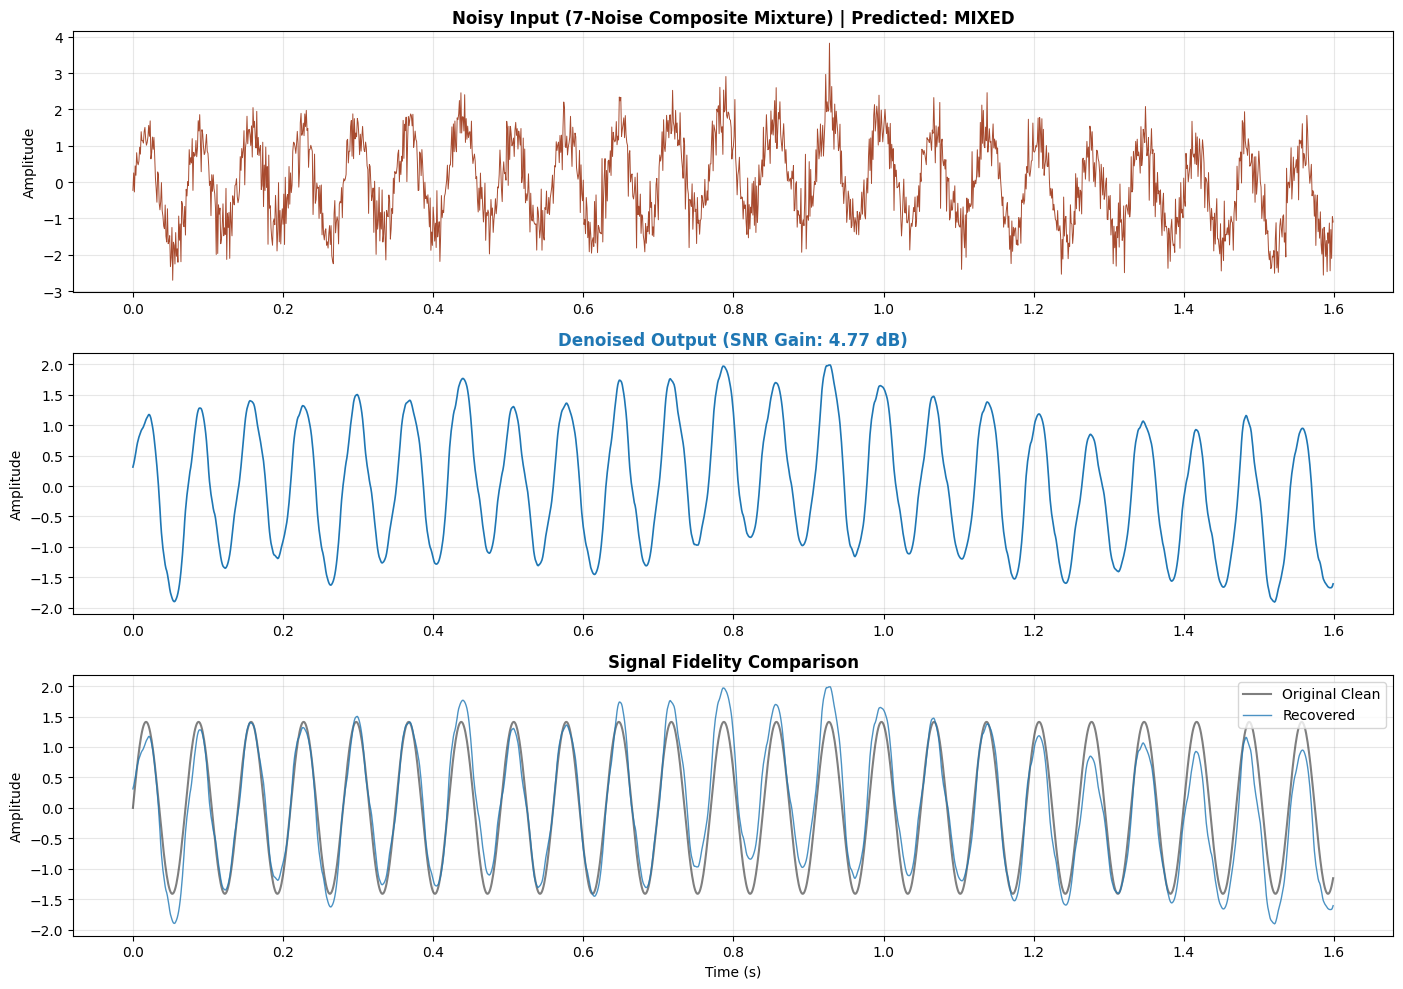

In [ ]:
# 1. Setup the Signal
rng = np.random.default_rng(SEED)
clean_ref = random_clean_signal(n=N, fs=FS, rng=rng)
# Generate the full 7-noise mixture from your previous cell
composite_noise = generate_all_noise_mixture(n=N, fs=FS, rng=rng)

# Add the composite noise to the clean signal at a challenging 5dB
noisy_composite, _ = add_noise_at_snr(clean_ref, composite_noise, snr_db=5.0, rng=rng)

# 2. Process through the ML Pipeline
# This will classify the mixture and apply the matched filter (Wavelet)
recovered_signal, pred_label, snr_hat = run_ml_denoise(noisy_composite)

# 3. Calculate Performance
in_snr = snr_db(clean_ref, noisy_composite)
out_snr = snr_db(clean_ref, recovered_signal)
gain = out_snr - in_snr

print(f"--- Full Mixture Denoising Results ---")
print(f"Predicted Category : {pred_label.upper()}")
print(f"Input SNR          : {in_snr:.2f} dB")
print(f"Output SNR         : {out_snr:.2f} dB")
print(f"Total SNR Gain     : {gain:.2f} dB")

# 4. Plotting the Results
t = np.arange(N)/FS
plt.figure(figsize=(14, 10))

# Subplot 1: Noisy Input (The 7-noise composite)
plt.subplot(3, 1, 1)
plt.plot(t, noisy_composite, color='#A84B2F', lw=0.7)
plt.title(f"Noisy Input (7-Noise Composite Mixture) | Predicted: {pred_label.upper()}", fontweight='bold')
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)

# Subplot 2: Denoised Output
plt.subplot(3, 1, 2)
plt.plot(t, recovered_signal, color='#1F77B4', lw=1.2)
plt.title(f"Denoised Output (SNR Gain: {gain:.2f} dB)", fontweight='bold', color='#1F77B4')
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)

# Subplot 3: Comparison (Overlay)
plt.subplot(3, 1, 3)
plt.plot(t, clean_ref, color='black', alpha=0.5, label='Original Clean', lw=1.5)
plt.plot(t, recovered_signal, color='#1F77B4', alpha=0.8, label='Recovered', lw=1)
plt.title("Signal Fidelity Comparison", fontweight='bold')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()